# Validate gene signature in external study with abatacept treatment

- ABT treatment: Iwasaki et al
  https://arthritis-research.biomedcentral.com/articles/10.1186/s13075-023-03236-y


In [1]:
quiet_library <- function(...) {
    suppressPackageStartupMessages(library(...))
}

quiet_library("tidyverse")
quiet_library("data.table")
quiet_library("ggplot2")
quiet_library("dplyr")
quiet_library("ggpubr")


In [2]:
# define the color palette to be used
npg_color <- c(
    "#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF",
    "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF"
)
npg_color_ext <- colorRampPalette(npg_color)(15)
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c(
    "#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A",
    "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999",
    "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00"
)
cluster_colors_ext <- colorRampPalette(cluster_colors)(36)
options(repr.plot.width = 20, repr.plot.height = 15)


In [3]:
# define working path
fig_path <- "/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/treatment_validation/figures"
output_path <- "/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/treatment_validation/output_results"
if (!dir.exists(fig_path)) (dir.create(fig_path, recursive = TRUE))
if (!dir.exists(output_path)) (dir.create(output_path, recursive = TRUE))
proj_name <- "ALTRA_AIM3_scRNA_validation_"


# ABT data from Iwasaki et al

paper https://arthritis-research.biomedcentral.com/articles/10.1186/s13075-023-03236-y


## Plot Fig S13A DEGs result for ABT responder

In [6]:
# load the deg table
dds_resp_res_tb <- read_csv('/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/treatment_validation/ALTRA_AIM3_scRNA_validation_responder_pre_post_degs.csv')


Rows: 13608 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): gene
dbl (6): baseMean, log2FoldChange, lfcSE, stat, pvalue, q_values

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


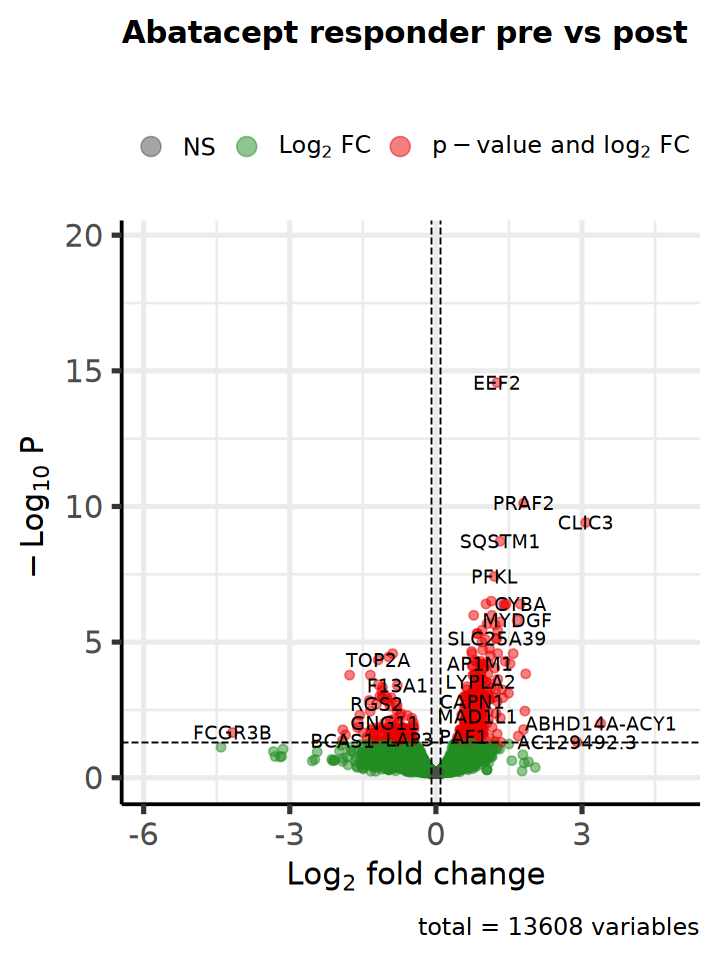

In [10]:
options(repr.plot.width = 6, repr.plot.height = 8)
# Plot the DA results for aim1
p1 <- EnhancedVolcano::EnhancedVolcano(dds_resp_res_tb,
    title = "Abatacept responder pre vs post",
    subtitle = "",
    lab = dds_resp_res_tb$gene,
    x = "log2FoldChange",
    y = "q_values",
    pCutoff = 0.05,
    FCcutoff = 0.1,
    pointSize = 2.0, # drawConnectors = TRUE,
    widthConnectors = 1.0,
    colConnectors = "black",
    arrowheads = FALSE,
    labSize = 4.0
) 
p1
ggsave(file.path(fig_path, paste0(proj_name, "Abatacept_responders_prevspost_valcano_plot.png")),
    width = 8, height = 6
)


## Plot Fig S13B DEGs result for ABT nonresponder

In [11]:
# load the deg table
dds_nonresp_res_tb <- read_csv('/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/treatment_validation/ALTRA_AIM3_scRNA_validation_nonresponder_pre_post_degs.csv')


Rows: 13275 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): gene
dbl (6): baseMean, log2FoldChange, lfcSE, stat, pvalue, q_values

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


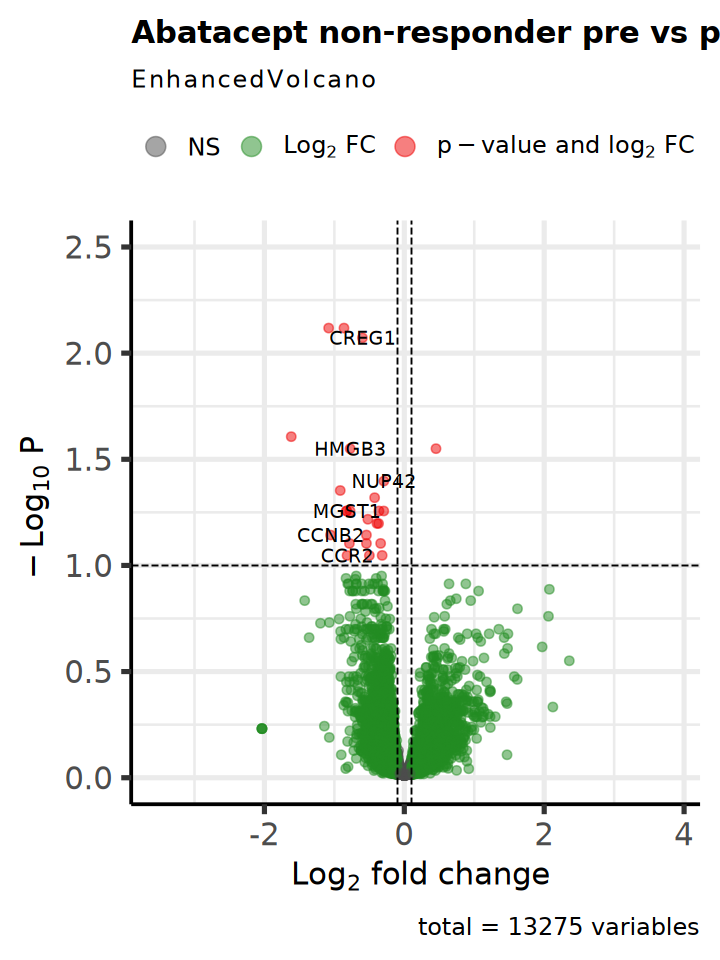

In [15]:
# Plot the DA results for aim1
p1 <- EnhancedVolcano::EnhancedVolcano(dds_nonresp_res_tb,
    title = "Abatacept non-responder pre vs post",
    lab = dds_nonresp_res_tb$gene,
    x = "log2FoldChange",
    y = "q_values",
    pCutoff = 0.1,
    FCcutoff = 0.1,
    pointSize = 2.0, # drawConnectors = TRUE,
    widthConnectors = 1.0,
    colConnectors = "black",
    arrowheads = FALSE,
    labSize = 4.0
)  + ylim(0, 2.5)
p1
ggsave(file.path(fig_path, paste0(proj_name, "Abatacept_nonresponders_prevspost_valcano_plot.png")),
    width = 8, height = 6
)


In [2]:
sessionInfo()

R version 4.4.3 (2025-02-28)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/r_scrna/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] ggpubr_0.6.1      data.table_1.17.6 lubridate_1.9.4   forcats_1.0.0    
 [5] stringr_1.5.1     dplyr_1.1.4       purrr_1.0.4       readr_2.1.5      
 [9] tidyr_1.3.1       tibble_3.3.0      ggplot2_3.5.2     tidyverse_2.0.0  

loaded via a namespace (and not attached):
 [1] gtable_0.3.6       jsonlite_2.0.0     ggs